# K Nearest Neighbours

## Assumptions
   1. KNN assumes data is in metric space and there is notation of distance
   2. Each of training data consists of a label data associated with it, either + or -.
      Although KNN also supports multiclass classification
   3. We are also given a asingle number "k".
      This number decides how many neighbours influence in the classification.
      This is usually a odd number.


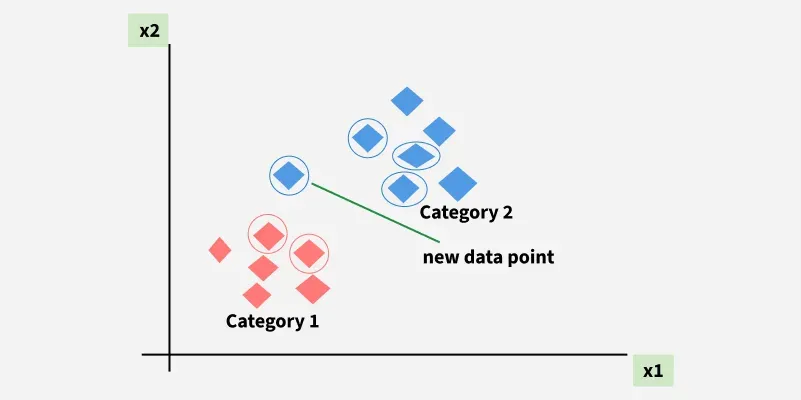

## Points to Consider
   1. Although in this example we are talking about a __2D__ - example but the concept holds true for __higher dimension__ as well.
   2. In this example we have taken a Euclidean distances into consideration but other distances are use as well
      like __Manattan Distance__ or __Minkowski distance__.
   3. It is suitable for only __low noise__ data.
   4. K-Nearest Neighbors is also called as a __lazy learner__ algorithm because it does not learn from the training set immediately
      instead it stores the entire dataset and performs computations only at the time of classification.
   5. E.g. : Recommendation Systems, Document Retrieval Systems, Gene Expression etc.

## How to find K?
### Method 1:
     K = sqrt( Number of data in training set )
     K should be odd to avoid ambiguity

### Method 2:
     Check accuracy for each value of K by Hit and Trial.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv('data.csv')
data.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [3]:
x = data.iloc[:,2:4]
y = data.iloc[:,-1].values

In [4]:
x.shape

(400, 2)

In [5]:
y.shape

(400,)

In [6]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [7]:
x = scaler.fit_transform(x)
x

array([[-1.78179743, -1.49004624],
       [-0.25358736, -1.46068138],
       [-1.11320552, -0.78528968],
       [-1.01769239, -0.37418169],
       [-1.78179743,  0.18375059],
       [-1.01769239, -0.34481683],
       [-1.01769239,  0.41866944],
       [-0.54012675,  2.35674998],
       [-1.20871865, -1.07893824],
       [-0.25358736, -0.13926283],
       [-1.11320552,  0.30121002],
       [-1.11320552, -0.52100597],
       [-1.6862843 ,  0.47739916],
       [-0.54012675, -1.51941109],
       [-1.87731056,  0.35993973],
       [-0.82666613,  0.30121002],
       [ 0.89257019, -1.3138571 ],
       [ 0.70154394, -1.28449224],
       [ 0.79705706, -1.22576253],
       [ 0.98808332, -1.19639767],
       [ 0.70154394, -1.40195167],
       [ 0.89257019, -0.60910054],
       [ 0.98808332, -0.84401939],
       [ 0.70154394, -1.40195167],
       [ 0.79705706, -1.37258681],
       [ 0.89257019, -1.46068138],
       [ 1.08359645, -1.22576253],
       [ 0.89257019, -1.16703281],
       [-0.82666613,

In [8]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.20)

In [9]:
x_train.shape

(320, 2)

In [10]:
x_test.shape

(80, 2)

In [11]:
# 1st method
np.sqrt(x_train.shape[0])

np.float64(17.88854381999832)

In [12]:
k = 17

In [13]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors = k)

In [14]:
# Train our model
knn.fit(x_train, y_train)
# Hyperparameters

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",17
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [15]:
y_pred = knn.predict(x_test)

In [16]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.925

In [17]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test, y_pred)

array([[48,  5],
       [ 1, 26]])

In [18]:
# Effect of K on Training Error rate and Validation Error rate

error_train = []
error_test = []

for i in range(1, 26):
    knn = KNeighborsClassifier(n_neighbors = i)
    knn.fit(x_train, y_train)
    accuracy_score(y_test, y_pred)
    x = confusion_matrix(y_train, knn.predict(x_train))
    y = confusion_matrix(y_test, knn.predict(x_test))
    error_train.append((x[0][1] + x[1][0]) / x.sum())
    error_test.append((y[0][1] + y[1][0]) / y.sum())


In [19]:
error_train

[np.float64(0.00625),
 np.float64(0.078125),
 np.float64(0.06875),
 np.float64(0.084375),
 np.float64(0.075),
 np.float64(0.0875),
 np.float64(0.075),
 np.float64(0.08125),
 np.float64(0.078125),
 np.float64(0.084375),
 np.float64(0.08125),
 np.float64(0.090625),
 np.float64(0.08125),
 np.float64(0.090625),
 np.float64(0.09375),
 np.float64(0.090625),
 np.float64(0.09375),
 np.float64(0.090625),
 np.float64(0.090625),
 np.float64(0.0875),
 np.float64(0.0875),
 np.float64(0.09375),
 np.float64(0.090625),
 np.float64(0.09375),
 np.float64(0.09375)]

In [20]:
error_test

[np.float64(0.125),
 np.float64(0.1),
 np.float64(0.0875),
 np.float64(0.1),
 np.float64(0.0875),
 np.float64(0.1),
 np.float64(0.1125),
 np.float64(0.1125),
 np.float64(0.0875),
 np.float64(0.0875),
 np.float64(0.0875),
 np.float64(0.0875),
 np.float64(0.0875),
 np.float64(0.0875),
 np.float64(0.0875),
 np.float64(0.075),
 np.float64(0.075),
 np.float64(0.075),
 np.float64(0.075),
 np.float64(0.075),
 np.float64(0.0875),
 np.float64(0.0875),
 np.float64(0.0875),
 np.float64(0.0875),
 np.float64(0.0875)]

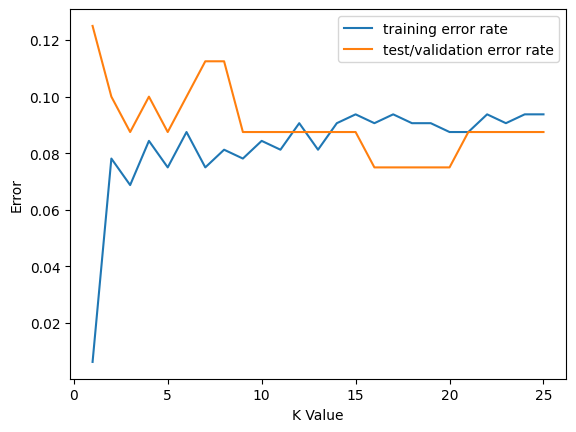

In [21]:
plt.plot(range(1,26), error_train, label = 'training error rate')
plt.plot(range(1,26), error_test, label = 'test/validation error rate')
plt.xlabel('K Value')
plt.ylabel('Error')
plt.legend()

In [22]:
def predict_output():
    age = int(input("Enter the age : "))
    salary = int(input("Enter the salary : "))

    x_new = np.array([[age], [salary]]).reshape(1, 2)
    x_new = scaler.transform(x_new)

    if knn.predict(x_new)[0] == 0:
        return "Will not purchase"
    else:
        return "Will purchase"

In [23]:
predict_output()

C:\Users\rafat\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


'Will purchase'

### Some Hyperparameters
#### n_jobs
     By default n_jobs has value 1, means it is using 1 core of CPU. Whereas, when n_jobs = -1, means it is using all of CUP's core.
     n_jobs can affect results in some cases, even though it is intended only to control parallelism.

#### n_neighbors
     It has value same as k

#### weights

     Custom Weight Function

     def my_weight(distances):
       return 1 / (distances + 1e-5)

     KNeighborsClassifier(weights=my_weight)

     weights='distance' makes KNN more robust and stable